In [1]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import diffrax
import matplotlib.pyplot as plt
import matplotlib as mpl
import met_brewer as mb
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MM_single_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True
colors = mb.met_brew(name="Egypt", n=3)

Set up: Models, data, etc.

In [ ]:
sampler = "ADVI"

cyto_color = colors[0]
lyso_color = colors[1]
mito_color = colors[2]

model = "MM_single"
model_info_file = '../models/MM_single.json'

data_dir = '../../../results/param_est/'
save_dir_base = '../../../results/param_est/stimulus_strength/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]


# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values()) # this is what we can modify to change the stimulus strength

# idata
idata_cyto = az.from_netcdf(data_dir + model + '_cyto_mcmc_samples_' + sampler + '.nc')
idata_lyso = az.from_netcdf(data_dir + model + '_lyso_mcmc_samples_' + sampler + '.nc')
idata_mito = az.from_netcdf(data_dir + model + '_mito_mcmc_samples_' + sampler + '.nc')

# load data to get simulation time
_, _, times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                        to_seconds=True, constant_std=False)

rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

Write a function to run all simulations and return the results. It takes the desired 
stimuli as the inputs

In [3]:
def run_model_sims(stim_strengths, idata, nsamples=4):

    # run the basal simulations once
    # can vmap solve over params if needed
    rhs = eval(model + '(' + ','.join(str(elm) for elm in basal_params) \
            + ')')
    rhs = diffrax.ODETerm(rhs)
    # rhs_stress = MM_single(*metab_params)
    
    # get params from the idata
    params = get_param_subsample(param_names, idata, nsamples)
   
    stress_sols = {}
    for key in stim_strengths.keys():
        # get the params for the current stimulus strength

        stress_params_mod = stress_params.copy()
        stress_params_mod[0] = stim_strengths[key] # update k_gly

        rhs_stress = eval(model + '(' + ','.join(str(elm) for elm in stress_params_mod) \
            + ')')
        
        rhs_stress = diffrax.ODETerm(rhs_stress)

        # run the stress sims
        tmp = []
        for j in range(params.shape[0]):
            stress_sol, _ = solve_traj(rhs, rhs_stress, y0, params[j,:], times, rtol=1e-6, atol=1e-6, 
               evnt_rtol = 1e-12, evnt_atol = 1e-12, tmax_init = 1e3, 
               pcoeff=0.3, icoeff=0.4, dcoeff=0.0,)
             
            AMPKAR_stressed = stress_sol[jnp.array(ampkar_idxs), :].sum(axis=0)
            pAMPKAR_stressed = stress_sol[jnp.array(pampkar_idxs), :].sum(axis=0)
            tmp.append(pAMPKAR_stressed/AMPKAR_stressed)

        stress_sols[key] = np.array(tmp)
    
    return stress_sols

Now actually run this. There is also the option to load previous results if they exist.

In [4]:
stim_strengths = {'0.4':0.4, # weakest stimulus (basal k_gly = 0.5)
                  '0.3':0.3,
                  '0.2':0.2,
                  '0.1':0.1,
                  '0.075':0.075,
                  '0.05':0.05,
                  '0.025':0.025,
                  '0.01':0.01,
                  '0.005':0.005, # level used during param est
                #   '0.0005':0.0005 # biggest stimulus (basal k_gly = 0.5)
                  }

run_sims = False
nsamples = 400
if run_sims:
    # run and save the simulations
    sol_cyto = run_model_sims(stim_strengths, idata_cyto, nsamples=nsamples)
    np.savez_compressed(save_dir + 'cyto_stim_strength.npz', **sol_cyto)

    sol_lyso = run_model_sims(stim_strengths, idata_lyso, nsamples=nsamples)
    np.savez_compressed(save_dir + 'lyso_stim_strength.npz', **sol_lyso)

    sol_mito = run_model_sims(stim_strengths, idata_mito, nsamples=nsamples)
    np.savez_compressed(save_dir + 'mito_stim_strength.npz', **sol_mito)
    print("Finished running simulations!")
else:
    print("Loading simulations from file...")
    try:
        # load the simulations
        sol_cyto = np.load(save_dir + 'cyto_stim_strength.npz')
        sol_lyso = np.load(save_dir + 'lyso_stim_strength.npz')
        sol_mito = np.load(save_dir + 'mito_stim_strength.npz')
    except FileNotFoundError as e:
        print("File not found. Please run the simulations first.")
        raise e

sol_cyto = {key: sol_cyto[key] for key in sol_cyto}
sol_lyso = {key: sol_lyso[key] for key in sol_lyso}
sol_mito = {key: sol_mito[key] for key in sol_mito}

Loading simulations from file...


Now process the results. Compute maximums and time to half maxes.

In [5]:
max_val_cyto = {stim:None for stim in stim_strengths.keys()}
t_half_max_cyto = {stim:None for stim in stim_strengths.keys()}
max_val_lyso = {stim:None for stim in stim_strengths.keys()}
t_half_max_lyso = {stim:None for stim in stim_strengths.keys()}
max_val_mito = {stim:None for stim in stim_strengths.keys()}
t_half_max_mito = {stim:None for stim in stim_strengths.keys()}

for stim in stim_strengths.keys():
    # get the max value and time to half max for each stimulus strength
    max_val_cyto[stim] = sol_cyto[stim][:,-1]
    max_val_lyso[stim] = sol_lyso[stim][:,-1]
    max_val_mito[stim] = sol_mito[stim][:,-1]

    # compute time to half max
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_cyto[stim])
    t_half_max_cyto[stim] = [times[idx] for idx in t_half_idx]
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_lyso[stim])
    t_half_max_lyso[stim] = [times[idx] for idx in t_half_idx]
    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol_mito[stim])
    t_half_max_mito[stim] = [times[idx] for idx in t_half_idx]

# convert to dataframes and merge cyto, lyso, mito
df_cyto = pd.DataFrame(max_val_cyto)
df_lyso = pd.DataFrame(max_val_lyso)
df_mito = pd.DataFrame(max_val_mito)

# Pivot the dataframes to a longer format
df_cyto_long = df_cyto.melt(var_name='stimulus_strength', value_name='max_val', ignore_index=False)
df_cyto_long['compartment'] = 'cyto'

df_lyso_long = df_lyso.melt(var_name='stimulus_strength', value_name='max_val', ignore_index=False)
df_lyso_long['compartment'] = 'lyso'

df_mito_long = df_mito.melt(var_name='stimulus_strength', value_name='max_val', ignore_index=False)
df_mito_long['compartment'] = 'mito'

# Combine the dataframes
max_vals = pd.concat([df_cyto_long, df_lyso_long, df_mito_long]).reset_index()
max_vals.rename(columns={'index': 'sample'}, inplace=True)

# t_half_max
df_cyto_t_half = pd.DataFrame(t_half_max_cyto)
df_lyso_t_half = pd.DataFrame(t_half_max_lyso)
df_mito_t_half = pd.DataFrame(t_half_max_mito)

# Pivot the dataframes to a longer format
df_cyto_t_half_long = df_cyto_t_half.melt(var_name='stimulus_strength', value_name='t_half_max', ignore_index=False)
df_cyto_t_half_long['compartment'] = 'cyto'
df_lyso_t_half_long = df_lyso_t_half.melt(var_name='stimulus_strength', value_name='t_half_max', ignore_index=False)
df_lyso_t_half_long['compartment'] = 'lyso'
df_mito_t_half_long = df_mito_t_half.melt(var_name='stimulus_strength', value_name='t_half_max', ignore_index=False)
df_mito_t_half_long['compartment'] = 'mito'
# Combine the dataframes
t_half_max_vals = pd.concat([df_cyto_t_half_long, df_lyso_t_half_long, df_mito_t_half_long]).reset_index()
t_half_max_vals.rename(columns={'index': 'sample'}, inplace=True)

# divide the t_half_max by 60 to get minutes
t_half_max_vals['t_half_max'] = t_half_max_vals['t_half_max']/60

Plots

/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/var

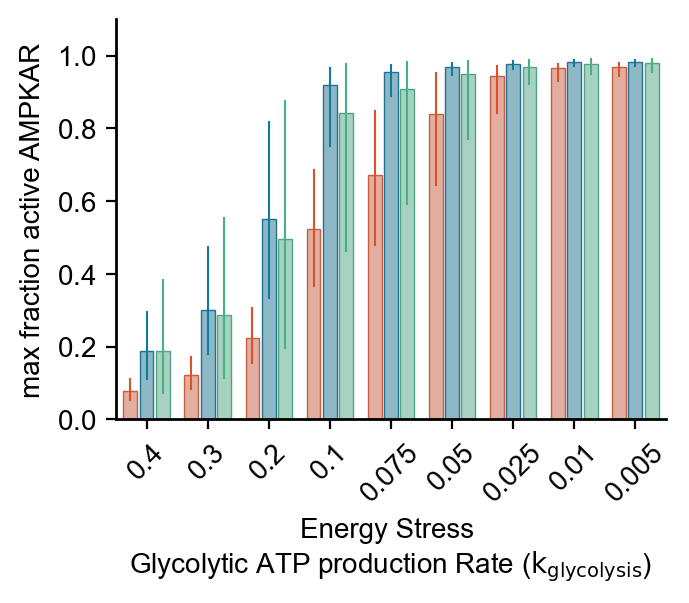

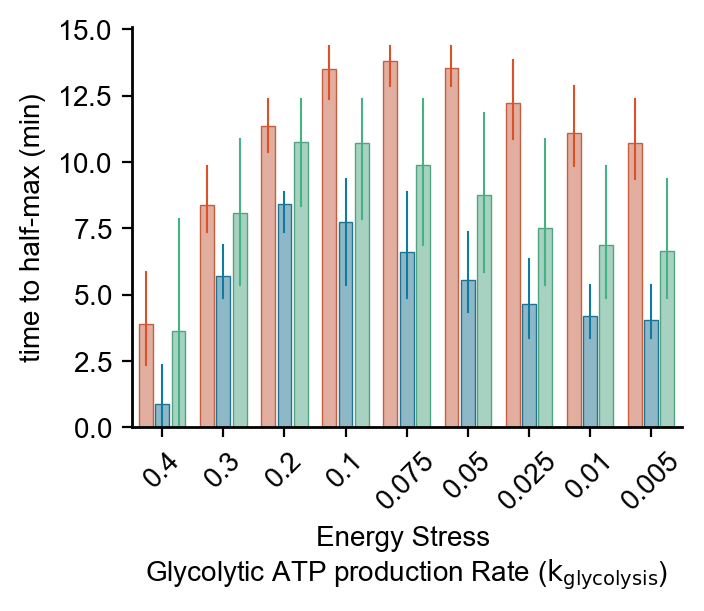

In [6]:
width = 2.75
height = 2.

# max vals
fig, ax = get_sized_fig_ax(width, height)

sns.barplot(data=max_vals, x='stimulus_strength', y='max_val', hue='compartment', palette=[cyto_color, lyso_color, mito_color], ax=ax,
    errorbar=('pi', 95), gap=0.15)
    # fliersize=False, whis=(0.025, 0.975))

ax.set_xlabel('Energy Stress \n'+r'Glycolytic ATP production Rate ($k_{glycolysis}$)', fontsize=10)
ax.set_ylabel('max fraction active AMPKAR', fontsize=10)
ax.legend(title='Compartment', loc='upper right')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

for patch in ax.patches:
    face_color = patch.get_facecolor()
    # Apply transparency to the face color only
    patch.set_facecolor(mpl.colors.to_rgba(face_color, alpha=0.5))  
    patch.set_edgecolor(face_color)  # Set edge color to match the fill
    patch.set_linewidth(0.5)  # Set transparency
    # patch.set_color(face_color)  # Set error color to match the fill

lines = ax.get_lines()
for i, line in enumerate(lines):
    if i  < 9:
        line.set_color(cyto_color)
    elif i >=9 and i < 18:
        line.set_color(lyso_color)
    else:
        line.set_color(mito_color)
    
    line.set_linewidth(0.75)

leg = ax.get_legend()
leg.remove()

fig.savefig(save_dir + 'max_vals.pdf', dpi=300, bbox_inches='tight',
    transparent=True)

# time to half max
fig, ax = get_sized_fig_ax(width, height)

sns.barplot(data=t_half_max_vals, x='stimulus_strength', y='t_half_max', hue='compartment', palette=[cyto_color, lyso_color, mito_color], 
            ax=ax, errorbar=('pi', 95), gap=0.15)

ax.set_xlabel('Energy Stress \n'+r'Glycolytic ATP production Rate ($k_{glycolysis}$)', fontsize=10)
ax.set_ylabel('time to half-max (min)', fontsize=10)
ax.legend(title='Compartment', loc='upper right')
# ax.set_ylim(0, 1.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

for patch in ax.patches:
    face_color = patch.get_facecolor()
    # Apply transparency to the face color only
    patch.set_facecolor(mpl.colors.to_rgba(face_color, alpha=0.5))  
    patch.set_edgecolor(face_color)  # Set edge color to match the fill
    patch.set_linewidth(0.5)  # Set transparency
    # patch.set_color(face_color)  # Set error color to match the fill

lines = ax.get_lines()
for i, line in enumerate(lines):
    if i < 9:
        line.set_color(cyto_color)
    elif i >=9 and i < 18:
        line.set_color(lyso_color)
    else:
        line.set_color(mito_color)
    
    line.set_linewidth(0.75)

leg = ax.get_legend()
leg.remove()

fig.savefig(save_dir + 't_half_max.pdf', dpi=300, bbox_inches='tight',
    transparent=True)